# Historical Product Demand — Exploratory Data Analysis

Dataset: `data/historical_product_demand.csv` — SKU-level order demand records for a manufacturer with warehouse operations, spanning 2011-2017.

Columns: `Product_Code`, `Warehouse`, `Product_Category`, `Date`, `Order_Demand`.

This notebook: data quality audit → cleaning → EDA → visualization → insights.

## 1. Setup & load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df_raw = pd.read_csv('../data/historical_product_demand.csv')
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (195928, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_1581,Whse_C,Category_005,2012/1/10,2000
1,Product_1581,Whse_C,Category_005,2012/2/9,2000
2,Product_1581,Whse_C,Category_005,2012/2/13,5000
3,Product_2015,Whse_C,Category_005,2012/2/24,2000
4,Product_1581,Whse_C,Category_005,2012/2/29,5000


In [2]:
df_raw.dtypes

Product_Code        str
Warehouse           str
Product_Category    str
Date                str
Order_Demand        str
dtype: object

## 2. Data quality overview

Before trusting any chart, audit the raw data for the usual EDA suspects: missing values, duplicate rows, and columns that look numeric but aren't.

In [3]:
print("Missing values per column:")
display(df_raw.isna().sum())

print("\nFully duplicated rows:", df_raw.duplicated().sum(),
      f"({df_raw.duplicated().mean():.1%} of all rows)")

non_numeric = df_raw['Order_Demand'].astype(str).str.contains(r'[^0-9]').sum()
print(f"\n'Order_Demand' is stored as text; {non_numeric} values use parentheses "
      f"(accounting notation for negatives, e.g. '(1000)') — these are returns/cancellations.")
display(df_raw.loc[df_raw['Order_Demand'].astype(str).str.contains(r'[^0-9]'), 'Order_Demand'].head())

Missing values per column:


Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


Fully duplicated rows: 21588 (11.0% of all rows)



'Order_Demand' is stored as text; 6512 values use parentheses (accounting notation for negatives, e.g. '(1000)') — these are returns/cancellations.


16472      (1)
16489     (24)
16490     (24)
16538     (50)
16539    (100)
Name: Order_Demand, dtype: str

**Data quality findings:**
- `Date` is missing for a meaningful share of rows — these rows carry no time information and must be excluded from time-series charts, but can still contribute to category/product/warehouse totals.
- `Order_Demand` is text, not numeric, because negative values (returns/cancellations) are written in parentheses.
- A large fraction of rows are exact duplicates. There's no order-ID column, so it's impossible to tell whether these are genuine repeat orders (e.g. the same SKU/warehouse/day/quantity ordered twice) or a data export artifact. They are **kept** rather than silently dropped, and flagged here as a caveat on any volume totals.

## 3. Cleaning

In [4]:
df = df_raw.copy()

# Order_Demand: parenthesized values are negative (returns/cancellations)
demand_str = df['Order_Demand'].astype(str)
is_negative = demand_str.str.startswith('(')
df['Order_Demand'] = demand_str.str.replace(r'[()]', '', regex=True).astype('int64')
df.loc[is_negative, 'Order_Demand'] *= -1
df['Is_Return'] = is_negative

# Date parsing
df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d', errors='coerce')
df['Year'] = df['Date'].dt.year

n = len(df)
print(f"Rows with missing/unparseable date: {df['Date'].isna().sum()} ({df['Date'].isna().mean():.1%})")
print(f"Rows flagged as returns (negative demand): {df['Is_Return'].sum()} ({df['Is_Return'].mean():.1%})")
print(f"Rows with zero demand: {(df['Order_Demand'] == 0).sum()} ({(df['Order_Demand'] == 0).mean():.1%})")
print(f"Fully duplicated rows (kept as-is): {df.duplicated().sum()} ({df.duplicated().mean():.1%})")
print(f"\nUnique products: {df['Product_Code'].nunique()}, categories: {df['Product_Category'].nunique()}, warehouses: {df['Warehouse'].nunique()}")
df[['Order_Demand', 'Is_Return']].describe()

Rows with missing/unparseable date: 11239 (5.7%)
Rows flagged as returns (negative demand): 6512 (3.3%)
Rows with zero demand: 24660 (12.6%)


Fully duplicated rows (kept as-is): 21588 (11.0%)

Unique products: 622, categories: 28, warehouses: 2


,Order_Demand
count,1.959280e+05
mean,3.700916e+03
std,2.840459e+04
min,-3.962000e+05
25%,5.000000e+00
50%,1.000000e+02
75%,1.000000e+03
max,3.000000e+06


In [5]:
print("Year coverage (row counts):")
display(df['Year'].value_counts().sort_index())
print("\n2011 and 2017 are fragment years (data starts 2011-01-08, ends 2017-01-09).")
print("Time-series charts below use the complete 2012-2016 window; category/product/warehouse totals use all rows.")

Year coverage (row counts):


Year
2011.0      273
2012.0    35107
2013.0    41541
2014.0    36311
2015.0    35649
2016.0    35796
2017.0       12
Name: count, dtype: int64


2011 and 2017 are fragment years (data starts 2011-01-08, ends 2017-01-09).
Time-series charts below use the complete 2012-2016 window; category/product/warehouse totals use all rows.


## 4. Univariate EDA

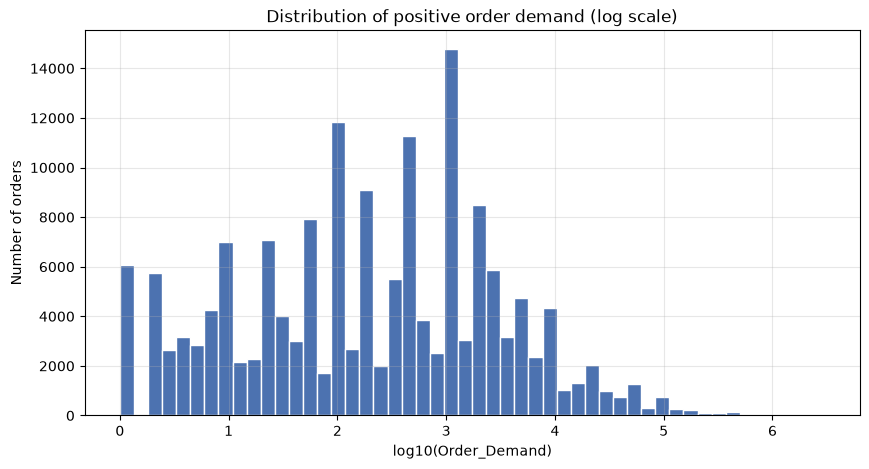

count    1.647560e+05
mean     4.458779e+03
std      3.085803e+04
min      1.000000e+00
25%      2.000000e+01
50%      2.000000e+02
75%      1.300000e+03
max      3.000000e+06
Name: Order_Demand, dtype: float64


In [6]:
positive = df.loc[df['Order_Demand'] > 0, 'Order_Demand']
fig, ax = plt.subplots()
ax.hist(np.log10(positive), bins=50, color='#4C72B0', edgecolor='white')
ax.set_xlabel('log10(Order_Demand)')
ax.set_ylabel('Number of orders')
ax.set_title('Distribution of positive order demand (log scale)')
plt.show()

print(positive.describe())

Demand is heavily right-skewed — the mean is pulled far above the median by a small number of very large orders. A log scale is needed to see the shape of the bulk of the distribution.

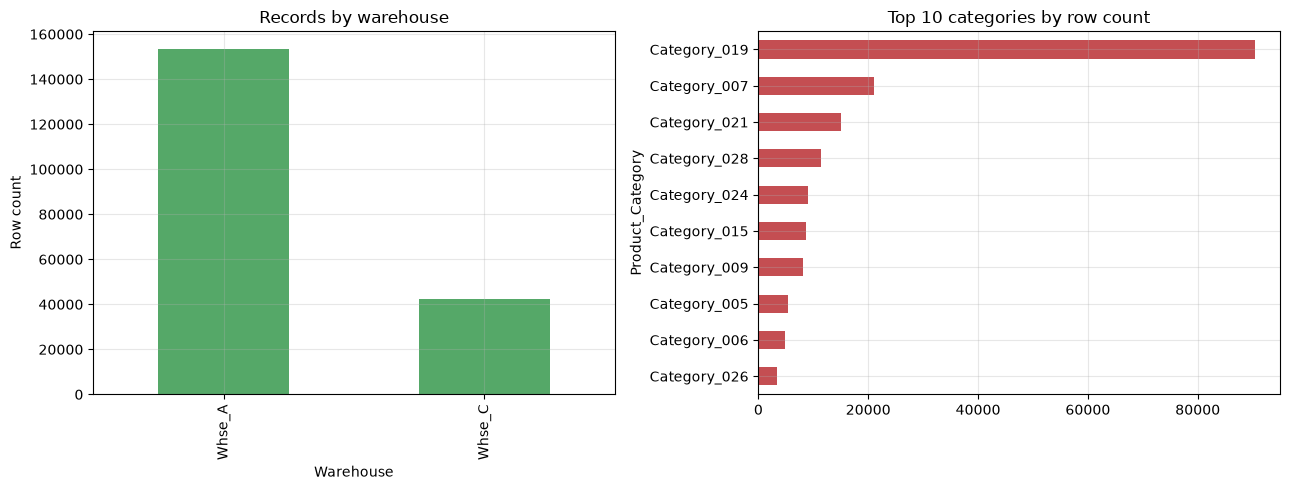

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df['Warehouse'].value_counts().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Records by warehouse')
axes[0].set_ylabel('Row count')

df['Product_Category'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 categories by row count')
plt.tight_layout()
plt.show()

Only **two warehouses** appear in the data (`Whse_A`, `Whse_C`) despite the company's stated global footprint — either the other sites aren't represented in this export, or operations are genuinely concentrated in these two locations. Worth confirming with the data owner before reading too much into warehouse comparisons below.

## 5. Time-series analysis

Restricted to rows with a valid date, and to the complete 2012-2016 window (2011 and 2017 are partial years that would distort month-over-month comparisons).

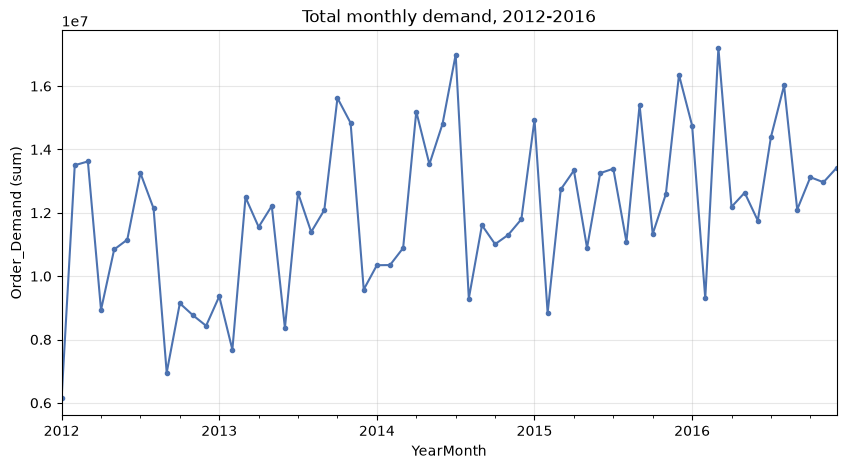

In [8]:
ts = df.dropna(subset=['Date'])
core = ts[(ts['Date'] >= '2012-01-01') & (ts['Date'] < '2017-01-01')].copy()
core['YearMonth'] = core['Date'].dt.to_period('M')

monthly = core.groupby('YearMonth')['Order_Demand'].sum()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots()
monthly.plot(ax=ax, marker='o', markersize=3, color='#4C72B0')
ax.set_title('Total monthly demand, 2012-2016')
ax.set_ylabel('Order_Demand (sum)')
plt.show()

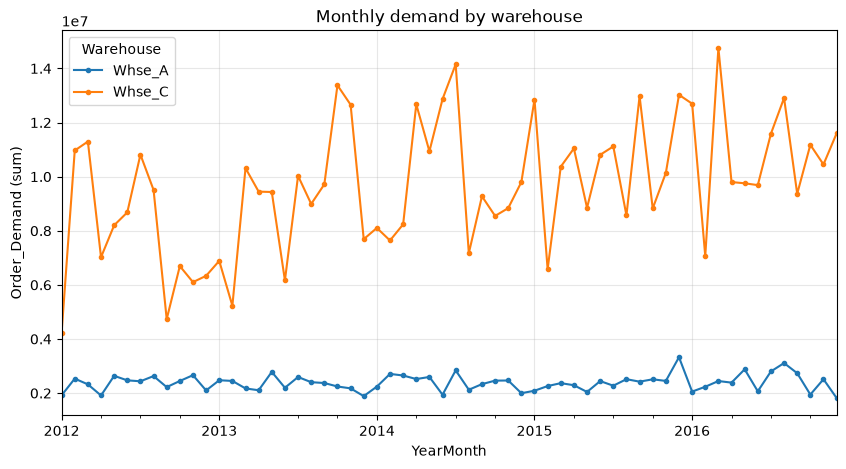

In [9]:
monthly_wh = core.groupby(['YearMonth', 'Warehouse'])['Order_Demand'].sum().unstack('Warehouse')
monthly_wh.index = monthly_wh.index.to_timestamp()

fig, ax = plt.subplots()
monthly_wh.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Monthly demand by warehouse')
ax.set_ylabel('Order_Demand (sum)')
plt.show()

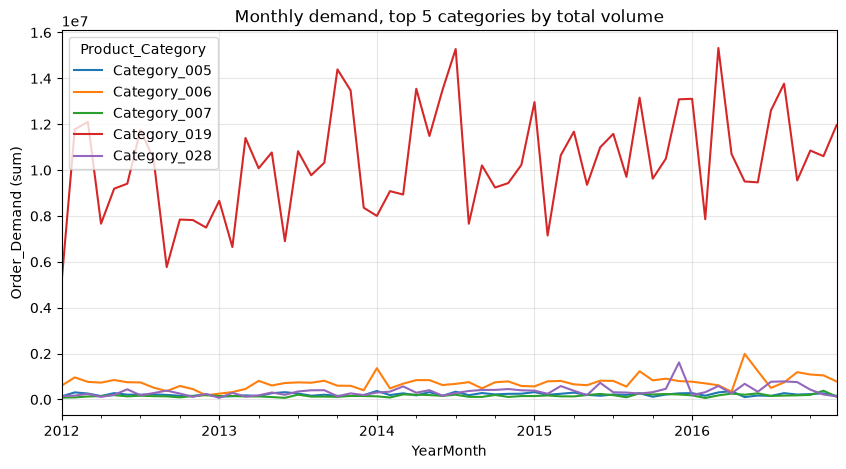

In [10]:
top5_cats = core.groupby('Product_Category')['Order_Demand'].sum().sort_values(ascending=False).head(5).index
monthly_cat = (core[core['Product_Category'].isin(top5_cats)]
               .groupby(['YearMonth', 'Product_Category'])['Order_Demand'].sum()
               .unstack('Product_Category'))
monthly_cat.index = monthly_cat.index.to_timestamp()

fig, ax = plt.subplots()
monthly_cat.plot(ax=ax)
ax.set_title('Monthly demand, top 5 categories by total volume')
ax.set_ylabel('Order_Demand (sum)')
plt.show()

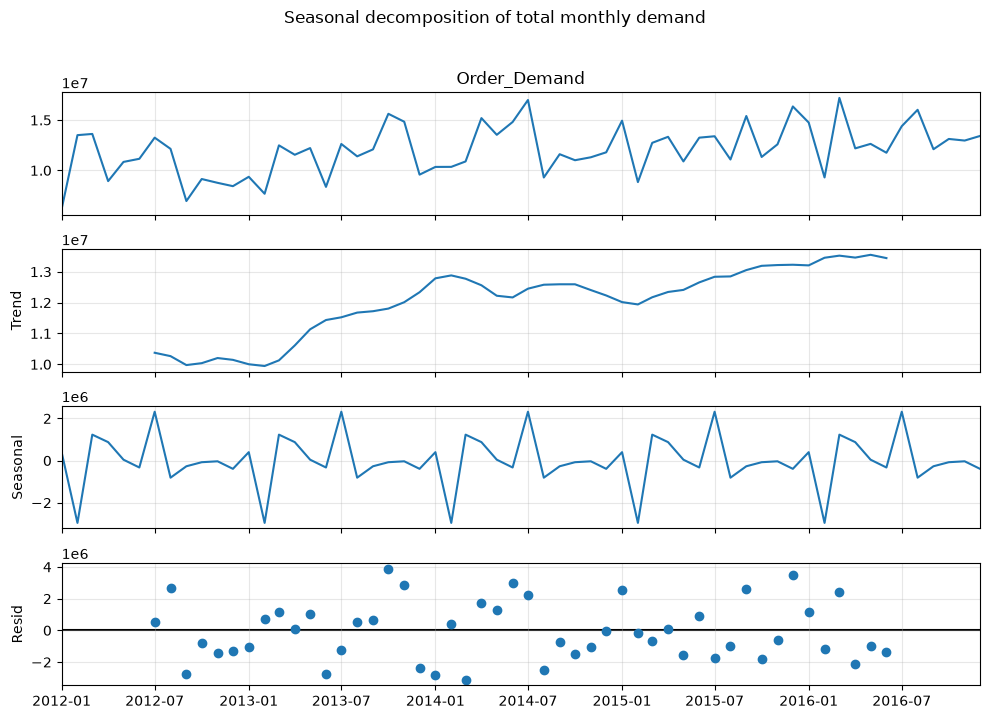

In [11]:
decomposition = seasonal_decompose(monthly, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.suptitle('Seasonal decomposition of total monthly demand', y=1.02)
plt.tight_layout()
plt.show()

## 6. Category & product concentration (Pareto)

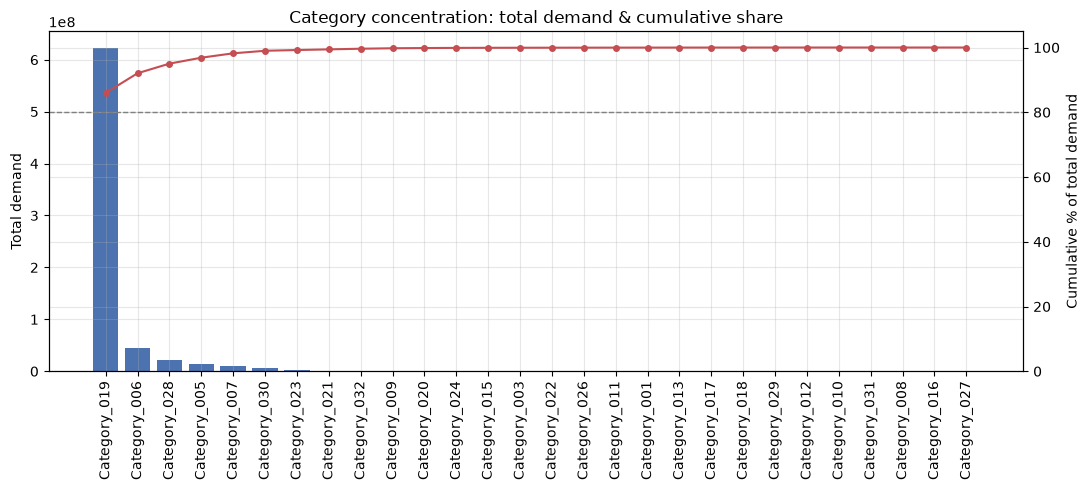

'Category_019' alone accounts for 86.0% of total demand volume.
1 of 28 categories account for 80% of total demand.


In [12]:
cat_totals = df.groupby('Product_Category')['Order_Demand'].sum().sort_values(ascending=False)
cat_cum_pct = cat_totals.cumsum() / cat_totals.sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(range(len(cat_totals)), cat_totals.values, color='#4C72B0')
ax1.set_xticks(range(len(cat_totals)))
ax1.set_xticklabels(cat_totals.index, rotation=90)
ax1.set_ylabel('Total demand')

ax2 = ax1.twinx()
ax2.plot(range(len(cat_totals)), cat_cum_pct.values, color='#C44E52', marker='o', markersize=4)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of total demand')
ax2.set_ylim(0, 105)

plt.title('Category concentration: total demand & cumulative share')
plt.tight_layout()
plt.show()

top_cat = cat_totals.index[0]
print(f"'{top_cat}' alone accounts for {cat_totals.iloc[0] / cat_totals.sum():.1%} of total demand volume.")
n_cats_80 = (cat_cum_pct <= 80).sum() + 1
print(f"{n_cats_80} of {len(cat_totals)} categories account for 80% of total demand.")

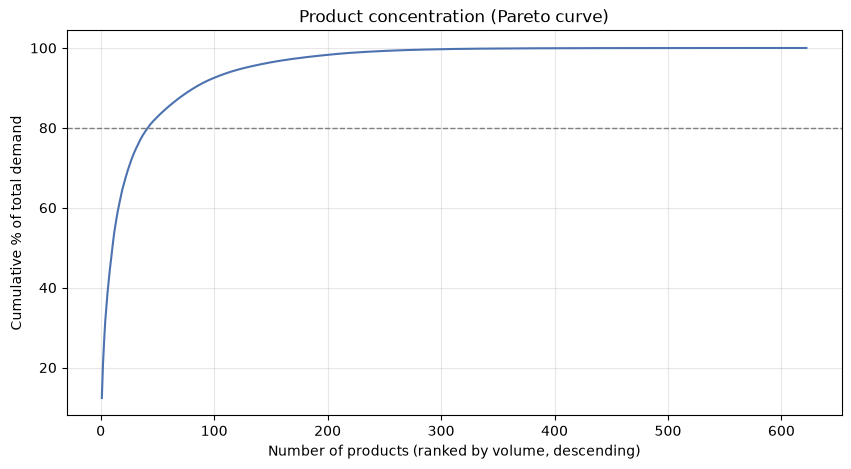

42 of 622 products (6.8%) account for 80% of total demand.

Top 10 products by total volume:


Product_Code
Product_1245    89778000
Product_1480    60567000
Product_1341    42672000
Product_1278    36265000
Product_1502    26250500
Product_1432    25042000
Product_1166    20775000
Product_1394    20412000
Product_1470    18233200
Product_1263    17927000
Name: Order_Demand, dtype: int64

In [13]:
prod_totals = df.groupby('Product_Code')['Order_Demand'].sum().sort_values(ascending=False)
prod_cum_pct = prod_totals.cumsum() / prod_totals.sum() * 100

fig, ax = plt.subplots()
ax.plot(range(1, len(prod_cum_pct) + 1), prod_cum_pct.values, color='#4C72B0')
ax.axhline(80, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Number of products (ranked by volume, descending)')
ax.set_ylabel('Cumulative % of total demand')
ax.set_title('Product concentration (Pareto curve)')
plt.show()

n_prod_80 = (prod_cum_pct <= 80).sum() + 1
print(f"{n_prod_80} of {len(prod_totals)} products ({n_prod_80/len(prod_totals):.1%}) account for 80% of total demand.")
print("\nTop 10 products by total volume:")
display(prod_totals.head(10))

## 7. Warehouse comparison

,total,mean,median,orders
Warehouse,,,,
Whse_A,143267773,932.890808,50.0,153574
Whse_C,581845212,13737.668508,1000.0,42354


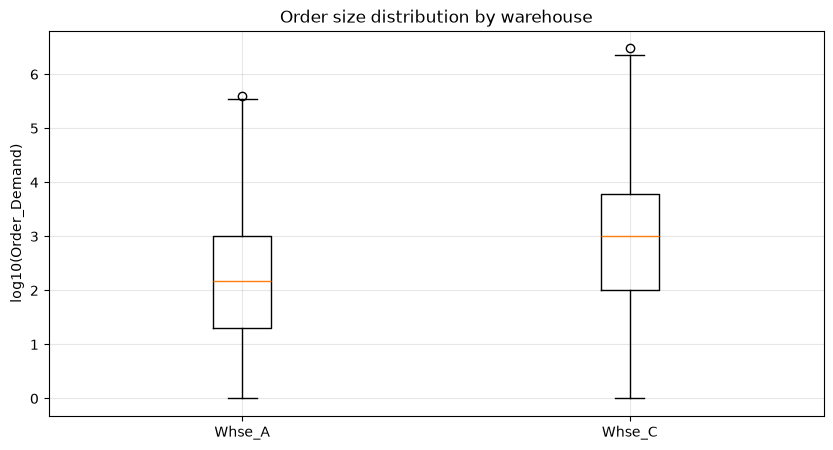

In [14]:
wh_stats = df.groupby('Warehouse')['Order_Demand'].agg(total='sum', mean='mean', median='median', orders='count')
display(wh_stats)

fig, ax = plt.subplots()
data_a = np.log10(df.loc[(df.Warehouse == 'Whse_A') & (df.Order_Demand > 0), 'Order_Demand'])
data_c = np.log10(df.loc[(df.Warehouse == 'Whse_C') & (df.Order_Demand > 0), 'Order_Demand'])
ax.boxplot([data_a, data_c], tick_labels=['Whse_A', 'Whse_C'])
ax.set_ylabel('log10(Order_Demand)')
ax.set_title('Order size distribution by warehouse')
plt.show()

## 8. Outliers & returns

In [15]:
top10 = df.nlargest(10, 'Order_Demand')[['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']]
print("Top 10 largest single orders:")
display(top10)

Top 10 largest single orders:


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
12772,Product_1341,Whse_C,Category_019,2012-02-06,3000000
174396,Product_1480,Whse_C,Category_019,2016-01-12,2300000
12773,Product_1341,Whse_C,Category_019,2012-03-05,2000000
92707,Product_1480,Whse_C,Category_019,2014-05-21,1600000
158018,Product_1245,Whse_C,Category_019,2016-04-05,1600000
158023,Product_1245,Whse_C,Category_019,2016-10-14,1600000
158024,Product_1245,Whse_C,Category_019,2016-12-08,1600000
133396,Product_1480,Whse_C,Category_019,2015-04-30,1584000
50315,Product_1480,Whse_C,Category_019,2013-10-11,1523000
50352,Product_1480,Whse_C,Category_019,2013-11-21,1396000


In [16]:
returns = df[df['Is_Return']]
gross = df.loc[df['Order_Demand'] > 0, 'Order_Demand'].sum()
net = df['Order_Demand'].sum()

print(f"Returns/cancellations: {len(returns):,} rows ({len(returns)/len(df):.1%} of all rows)")
print(f"Total units returned: {-returns['Order_Demand'].sum():,.0f}")
print(f"Gross demand (positive orders only): {gross:,.0f}")
print(f"Net demand (gross - returns): {net:,.0f}")
print(f"Returns are {(gross - net) / gross:.2%} of gross demand")

print("\nCategories with the largest returned volume:")
display(returns.groupby('Product_Category')['Order_Demand'].sum().sort_values().head(10))

Returns/cancellations: 6,512 rows (3.3% of all rows)
Total units returned: 9,497,620
Gross demand (positive orders only): 734,610,605
Net demand (gross - returns): 725,112,985
Returns are 1.29% of gross demand

Categories with the largest returned volume:


Product_Category
Category_019   -7927523
Category_028    -795820
Category_006    -355516
Category_005    -177900
Category_007     -95092
Category_009     -55128
Category_021     -44337
Category_030     -13500
Category_020      -7013
Category_024      -5716
Name: Order_Demand, dtype: int64

## 9. Insights summary

1. **One category dominates volume, not just row count.** `Category_019` accounts for 86% of total order volume (and 46% of rows) — a single category, and just 1 of 28 total, crosses the 80% cumulative-volume threshold on its own. Demand planning and forecasting effort should be weighted almost entirely toward getting this one category right.
2. **Product-level concentration is sharp too, but less extreme.** Just 42 of 622 SKUs (6.8%) drive 80% of total demand — a classic long tail where the majority of catalog items are low-volume/niche.
3. **The two warehouses serve different roles, not just different sizes.** `Whse_A` handles far more orders (153,574 vs 42,354) but at much smaller average size (mean 933, median 50 units) — consistent with frequent, smaller-batch fulfillment. `Whse_C` handles fewer orders but far larger ones (mean 13,738, median 1,000 units) and produces **4x Whse_A's total volume** (581.8M vs 143.3M units) — consistent with bulk/wholesale shipments. All of the top 10 single largest orders (up to 3,000,000 units) come from Whse_C, Category_019. Also note: despite the "global footprint" framing, only these two warehouse codes appear in the data — worth confirming with the data owner whether other sites are simply missing from this export.
4. **Data quality needs fixing before this feeds any downstream model.** 5.7% of rows have no date (unusable for time-series, still usable for category/product rollups), 11.0% are exact duplicate rows with no order-ID to disambiguate genuine repeat orders from export artifacts, and `Order_Demand` requires string cleanup (parenthesized values are negative returns) before any numeric aggregation is valid.
5. **Returns are a small but concentrated drag on net demand.** 6,512 rows (3.3%) are returns/cancellations, netting out to 1.29% of gross demand (net 725.1M vs gross 734.6M units) — but the returns are heavily concentrated in `Category_019` (-7.93M units), which also happens to be the dominant volume category, so return-rate-by-category is worth tracking even though the aggregate impact looks small.
6. **Outlier orders are real and category/warehouse-specific, not noise scattered across the dataset.** The single largest order is 3,000,000 units (2012-02-06, Whse_C, Category_019); every one of the top 10 largest orders shares that same category/warehouse combination — these look like legitimate large-batch orders for one product line rather than data entry errors, but should be confirmed with the business before being treated as routine in any forecasting model (they will dominate a naive mean/sum-based forecast).